# TP 3.1 : Test de Student

Nous nous intéressons ici au test de Student de comparaison des moyennes sur 2 échantillons indépendants simulés selon des lois normales de même variance $\sigma^2 > 0$,
\begin{equation*}
X_1,\dots,X_p \sim \mathcal{N}(m_X,\sigma^2) \quad \text{et} \quad Y_1,\dots,Y_q \sim \mathcal{N}(m_Y,\sigma^2).
\end{equation*}
Pour expérimenter, nous prendrons $p=q=10$, $m_X=m_Y=0$ et $\sigma^2=1$.

In [3]:
# Génération des échantillons
x <- rnorm(10)
y <- rnorm(10)

Le test bilatéral de comparaison des moyennes sur ces 2 échantillons se fait en utilisant la fonction `t.test()` avec l'option `var.equal=TRUE`.

In [19]:
# Test bilatéral de comparaison des moyennes
resultat_test <- t.test(x, y, var.equal=TRUE)

# L'objet obtenu contient beaucoup d'informations
resultat_test


	Two Sample t-test

data:  x and y
t = -0.90238, df = 18, p-value = 0.3788
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1.2044615  0.4806711
sample estimates:
 mean of x  mean of y 
-0.1351614  0.2267338 


Utilisez la cellule suivante pour répondre aux questions :

1. Donner l'hypothèse nulle $H_0$ et l'hypothèse alternative $H_1$ de ce test.

2. Pourquoi faut-il supposer que les deux échantillons aient la même variance ?  
   En particulier, quelle est la loi de la variable  
   $$
   (p+q-2)\frac{\tilde{\sigma}^2_{p,q}}{\sigma^2} \quad \text{où} \quad 
   \tilde{\sigma}^2_{p,q} = \frac{1}{p+q-2}\sum_{k=1}^p\left( X_k - \bar{X}_p \right)^2 + \frac{1}{p+q-2}\sum_{k=1}^q\left( Y_k - \bar{Y}_q \right)^2
   $$

3. En déduire la loi de la statistique de test  
   $$
   T = \sqrt{\frac{pq}{p+q}} \times \frac{\bar{X}_p - \bar{Y}_q}{\sqrt{\tilde{\sigma}^2_{p,q}}}.
   $$

4. Vérifier le calcul de la statistique de test donné dans `resultat_test`.

5. Quelle est la p-valeur du test `resultat_test` ?  
   Pour un niveau de 95%, doit-on accepter ou rejeter $H_0$ ?  
   Est-ce cohérent avec notre simulation initiale ?

6. Recalculer cette p-valeur à partir d'une loi de Student à 18 degrés de liberté.

In [ ]:
# À FAIRE

# 1
# L'hypothèse nulle du test est que les deux échantillons ont la même moyenne.
# L'hypothèse alternative est que les deux échantillons ont des moyennes différentes.

# 2
# sinon ca ne suit pas une loi de Student ?
# Loi de chi2 à à p + q − 2 degrés de liberté

# 3
# Ca suit une loi de studen

# 4
S <- (9*var(x) + 9*var(y))/(18)
print(S)
t <- sqrt(100/20)*(mean(x)-mean(y))/sqrt(S)
print(t)

# On accepte car p_valeur > 0.05

# 6
p_value_two_tail <- 2 * (1 - pt(abs(t), 18))
print(p_value_two_tail)


[1] 0.8041893
[1] -0.9023783
[1] 0.3787731


Pour illustrer la notion de niveau d'un test, nous simulons 1000 paires d'échantillons de taille 10 comme ci-dessus et nous les stockons dans deux matrices `X` et `Y`.

In [23]:
X <- matrix(rnorm(1000*10), nrow=1000)
Y <- matrix(rnorm(1000*10), nrow=1000)

<div class="alert alert-block alert-success">
    Utilisez la cellule suivante pour répondre aux questions :
    <ol>
        <li>Effectuer un test de comparaison des moyennes pour chaque paire d'échantillons et stocker la p-valeur du résultat dans un vecteur <code>p_valeur</code> de taille 1000.</li>
        <li>Combien de p-valeurs inférieures à 0.05 obtenez-vous ? Combien devriez-vous théoriquement en obtenir en moyenne ?</li>
        <li>Repérer l'indice du test qui donne la plus petite p-valeur (il peut être utile d'utiliser la fonction <code>which.min()</code>). Pour un niveau de 95%, doit-on accepter ou rejeter $H_0$ pour ce test ?</li>
        <li>Représenter graphiquement les données correspondant à ce test :
            <ul>
                <li>afficher la densité de la loi normale centrée réduite entre -3 et 3 avec <code>plot(dnorm, -3, 3, type="l")</code>,</li>
                <li>afficher les deux échantillons avec deux couleurs différentes grâce à la fonction <code>rug()</code>,</li>
                <li>afficher les moyennes des deux échantillons (fonction <code>rug()</code>),</li>
                <li>ajouter une légende.</li>
            </ul>
            <center><img src="img/student.png"></center>
        </li>
    </ol>
</div>

[1] 50

[1] 0.0001791417

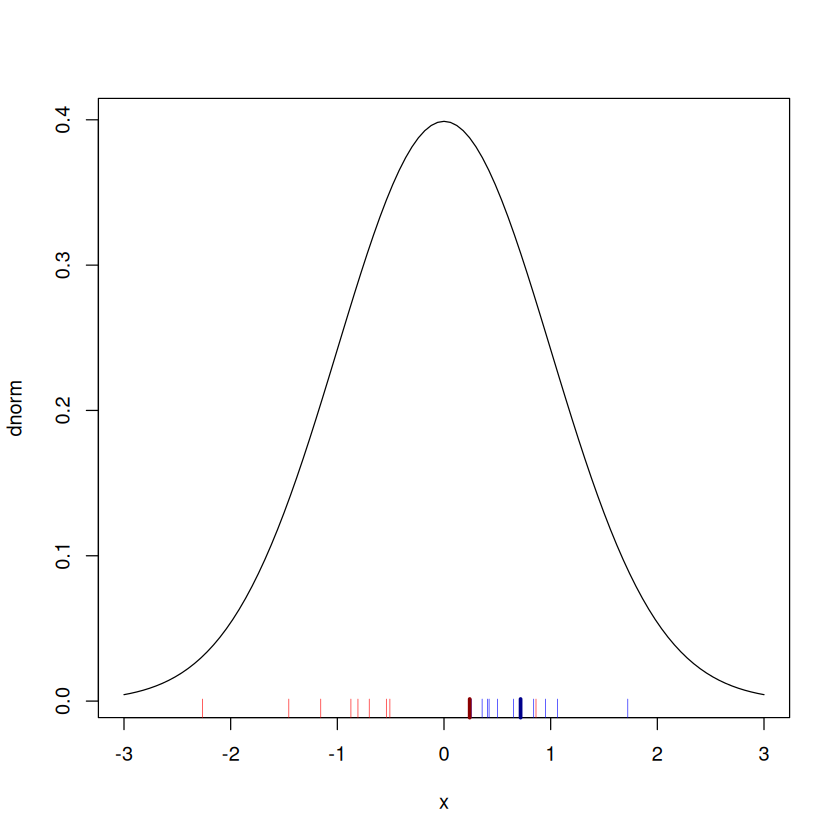

In [41]:
# À FAIRE
# 1
for (i in 1:1000) {
  resultat_test <- t.test(X[i,], Y[i,], var.equal=TRUE)
  p_valeur[i] <- resultat_test$p.value
}

# 2
length(p_valeur[p_valeur < 0.05])

# 3
i <- which.min(p_valeur)
p_valeur[i]

#4
par(bg = "white")
plot(dnorm, -3, 3, type = "l")
rug(X[i,],col = "blue")
rug(Y[i,], col = "red")

mean_X <- mean(X[i,])
mean_Y <- mean(Y[i])

rug(mean_X, col="darkblue", lwd=3)
rug(mean_Y, col="darkred", lwd=3)

